# 🏆 DATATHON 2026 — EDA: Customer Journey Analysis## Breaking Business Boundaries | Team DATACONDA**Framework:** Phân tích theo hành trình khách hàng 5 giai đoạn  **Dữ liệu:** Doanh nghiệp thời trang TMĐT Việt Nam (07/2012 – 12/2022)| Giai đoạn | Tên | Câu hỏi chính ||---|---|---|| 0 | Macro View | Bức tranh toàn cảnh doanh thu || 1 | Acquisition | Tiền đổ vào đâu hiệu quả? || 2 | Behavior | Khách hàng muốn gì? || 3 | Conversion | Tại sao khách bỏ cuộc? || 4 | Retention | Làm sao để họ quay lại? |

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.dates import DateFormatter  # Đã sửa lỗi dính chữ
import warnings
import sys

warnings.filterwarnings('ignore')

# ── Style ──
plt.rcParams.update({    
    'figure.figsize': (14, 6), 
    'figure.dpi': 120, 
    'figure.facecolor': '#0d1117',    
    'axes.facecolor': '#161b22', 
    'axes.edgecolor': '#30363d', 
    'axes.labelcolor': '#c9d1d9',    
    'axes.grid': True, 
    'grid.color': '#21262d', 
    'grid.alpha': 0.6, 
    'text.color': '#c9d1d9', 
    'xtick.color': '#8b949e', 
    'ytick.color': '#8b949e', 
    'font.size': 11, 
    'axes.titlesize': 14, 
    'legend.facecolor': '#161b22',    
    'legend.edgecolor': '#30363d',
})

PALETTE = ['#58a6ff', '#f78166', '#3fb950', '#d2a8ff', '#f0883e', '#79c0ff', '#56d364']
sns.set_palette(PALETTE)

# ── Load Data ──
sys.path.insert(0, '..')
from joined.data_pipeline import (
    load_transaction_master, 
    load_daily_summary, 
    load_returns_enriched, 
    load_reviews_enriched
)

txn = load_transaction_master()
daily = load_daily_summary()
ret = load_returns_enriched()
rev = load_reviews_enriched()

# Additional raw tables
customers = pd.read_csv('../dataset_cleaned/customers.csv', parse_dates=['signup_date'])
promotions = pd.read_csv('../dataset_cleaned/promotions.csv', parse_dates=['start_date', 'end_date'])
web = pd.read_csv('../dataset_cleaned/web_traffic.csv', parse_dates=['date'])
inventory = pd.read_csv('../dataset_cleaned/inventory.csv', parse_dates=['snapshot_date'])
orders = pd.read_csv('../dataset_cleaned/orders.csv', parse_dates=['order_date'])

# Đảm bảo định dạng datetime
daily['date'] = pd.to_datetime(daily['date'])
txn['order_date'] = pd.to_datetime(txn['order_date'])

print(f"✅ Data loaded: txn={len(txn):,} | daily={len(daily):,} | ret={len(ret):,} | rev={len(rev):,}")
print(f"    Customers={len(customers):,} | Orders={len(orders):,}")

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.

---# 📊 Giai đoạn 0: Bức Tranh Toàn Cảnh (Macro View)> **Descriptive + Predictive:** Doanh thu tổng thể, xu hướng tăng trưởng, mùa vụ, vùng miền

### 0.1 Doanh thu theo thời gian + Moving Average

NameError: name 'daily' is not defined

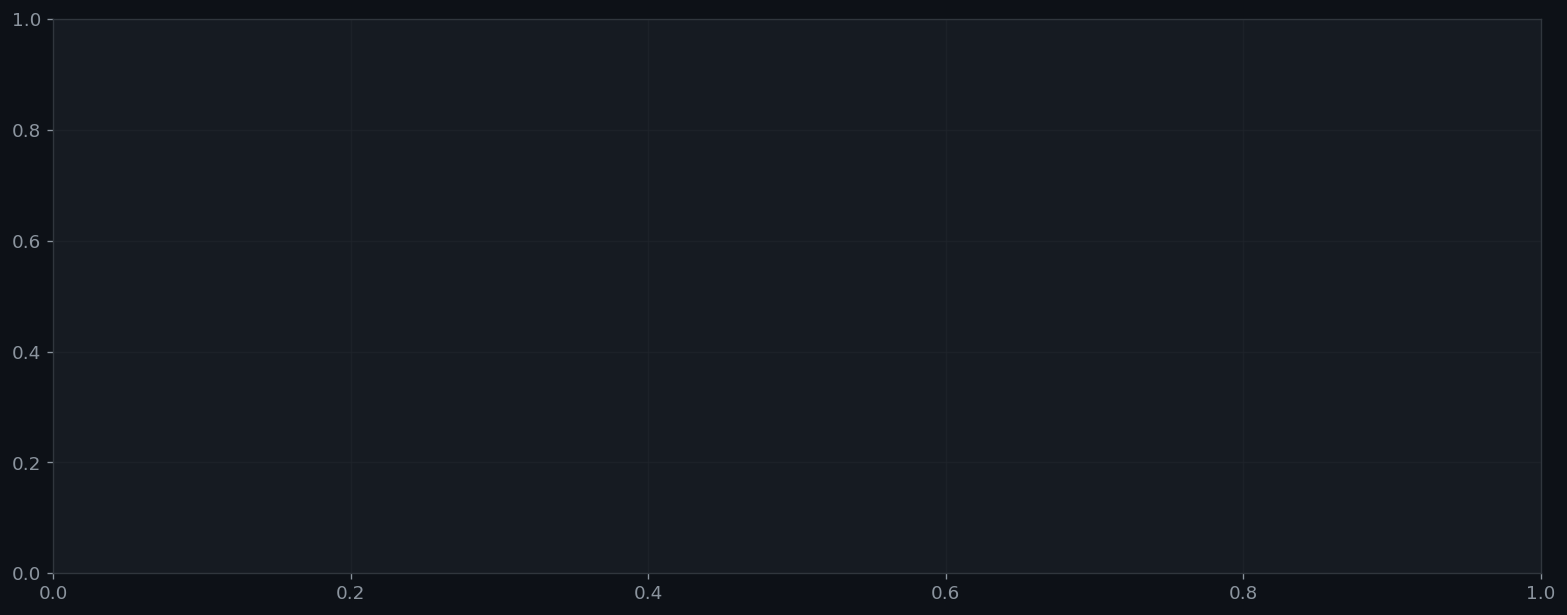

In [3]:
fig, ax = plt.subplots(figsize=(16, 6))
daily_sorted = daily.sort_values('date')

# Vẽ các đường biểu diễn doanh thu
ax.plot(daily_sorted['date'], daily_sorted['revenue']/1e6, alpha=0.3, color=PALETTE[0], linewidth=0.5, label='Daily')
ax.plot(daily_sorted['date'], daily_sorted['revenue'].rolling(30).mean()/1e6, color=PALETTE[0], linewidth=2, label='MA-30')
ax.plot(daily_sorted['date'], daily_sorted['revenue'].rolling(365).mean()/1e6, color=PALETTE[2], linewidth=2.5, label='MA-365 (Trend)')

# Cấu hình trục và tiêu đề
ax.set_title('📈 Doanh thu hàng ngày & Xu hướng dài hạn', fontsize=16, fontweight='bold')
ax.set_ylabel('Revenue (Triệu VND)')
ax.legend(framealpha=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}M'))

plt.tight_layout()
plt.show()

# Key stats
total_rev = daily['revenue'].sum()
avg_daily = daily['revenue'].mean()

print(f"💰 Tổng doanh thu: {total_rev/1e9:,.1f} tỷ VND")
print(f"📊 Doanh thu TB/ngày: {avg_daily/1e6:,.1f} triệu VND")

### 0.2 Tăng trưởng doanh thu YoY (Year-over-Year)

In [ ]:
yearly = daily.groupby('year').agg(revenue=('revenue','sum'), cogs=('cogs','sum')).reset_index()yearly['profit'] = yearly['revenue'] - yearly['cogs']yearly['yoy_growth'] = yearly['revenue'].pct_change() * 100fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))# Revenue + COGS barsx = range(len(yearly))ax1.bar(x, yearly['revenue']/1e9, color=PALETTE[0], alpha=0.8, label='Revenue')ax1.bar(x, yearly['cogs']/1e9, color=PALETTE[1], alpha=0.6, label='COGS')ax1.set_xticks(x); ax1.set_xticklabels(yearly['year'].astype(int))ax1.set_title('Doanh thu & Giá vốn theo năm', fontweight='bold')ax1.set_ylabel('Tỷ VND'); ax1.legend()# YoY growthcolors = [PALETTE[2] if v > 0 else PALETTE[1] for v in yearly['yoy_growth'].fillna(0)]ax2.bar(x[1:], yearly['yoy_growth'].iloc[1:], color=colors[1:], alpha=0.8)ax2.axhline(0, color='#8b949e', linestyle='--', alpha=0.5)ax2.set_xticks(x); ax2.set_xticklabels(yearly['year'].astype(int))ax2.set_title('Tốc độ tăng trưởng YoY (%)', fontweight='bold')ax2.set_ylabel('%')for i, v in enumerate(yearly['yoy_growth'].iloc[1:], 1):    ax2.text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=9, color='#c9d1d9')plt.tight_layout(); plt.show()

### 0.3 Phân tích Mùa vụ — Revenue Heatmap theo Tháng × Năm

In [ ]:
monthly = daily.groupby(['year', 'month'])['revenue'].sum().reset_index()pivot = monthly.pivot(index='year', columns='month', values='revenue')fig, ax = plt.subplots(figsize=(14, 7))sns.heatmap(pivot/1e6, annot=True, fmt=',.0f', cmap='YlOrRd', linewidths=0.5,            ax=ax, cbar_kws={'label': 'Revenue (Triệu VND)'})ax.set_title('🗓️ Revenue Heatmap: Tháng × Năm (Triệu VND)', fontsize=16, fontweight='bold')ax.set_xlabel('Tháng'); ax.set_ylabel('Năm')plt.tight_layout(); plt.show()print("📌 Insight: Tháng 11–12 luôn có doanh thu cao nhất (Mega Sale Q4)")print(f"   Doanh thu TB T11-12: {monthly[monthly['month'].isin([11,12])]['revenue'].mean()/1e6:,.0f}M")print(f"   Doanh thu TB T1-T3: {monthly[monthly['month'].isin([1,2,3])]['revenue'].mean()/1e6:,.0f}M")

### 0.4 Phân bổ doanh thu theo Vùng miền

In [ ]:
delivered = txn[txn['order_status'].isin(['delivered', 'shipped'])]region_rev = delivered.groupby('region').agg(    revenue=('line_revenue', 'sum'), orders=('order_id', 'nunique'),    customers=('customer_id', 'nunique'), avg_margin=('gross_margin', 'mean')).reset_index().sort_values('revenue', ascending=False)fig, axes = plt.subplots(1, 3, figsize=(16, 5))# Revenue pieaxes[0].pie(region_rev['revenue'], labels=region_rev['region'], autopct='%1.1f%%',            colors=PALETTE[:3], textprops={'color': '#c9d1d9'})axes[0].set_title('Tỷ trọng Doanh thu', fontweight='bold')# Orders baraxes[1].barh(region_rev['region'], region_rev['orders'], color=PALETTE[:3])axes[1].set_title('Số đơn hàng', fontweight='bold')for i, v in enumerate(region_rev['orders']):    axes[1].text(v + 500, i, f'{v:,}', va='center', fontsize=10, color='#c9d1d9')# Margin baraxes[2].barh(region_rev['region'], region_rev['avg_margin']*100, color=PALETTE[:3])axes[2].set_title('Biên LN gộp TB (%)', fontweight='bold')for i, v in enumerate(region_rev['avg_margin']*100):    axes[2].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=10, color='#c9d1d9')plt.tight_layout(); plt.show()

### 0.5 ⚠️ Data Quality Insight: 382 ngày Lợi nhuận Âm (Loss-Leader)

In [ ]:
sales_clean = pd.read_csv('../dataset_cleaned/sales.csv', parse_dates=['Date'])loss_days = sales_clean[sales_clean['is_loss_leader_day'] == 1].copy()loss_days['month'] = loss_days['Date'].dt.monthfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))# Distribution by monthloss_by_month = loss_days.groupby('month').size()ax1.bar(loss_by_month.index, loss_by_month.values, color=PALETTE[1], alpha=0.8)ax1.set_title('Số ngày lỗ theo Tháng', fontweight='bold')ax1.set_xlabel('Tháng'); ax1.set_ylabel('Số ngày')# Loss amount distributionax2.hist(loss_days['gross_profit']/1e6, bins=30, color=PALETTE[1], alpha=0.7, edgecolor='white')ax2.axvline(0, color='white', linestyle='--', alpha=0.5)ax2.set_title('Phân phối mức lỗ (Triệu VND)', fontweight='bold')ax2.set_xlabel('Gross Profit (Triệu VND)')plt.tight_layout(); plt.show()total_loss = loss_days['gross_profit'].sum()print(f"🔴 Tổng thiệt hại: {total_loss/1e6:,.0f} triệu VND trong {len(loss_days)} ngày")print(f"🔴 Trung bình mỗi ngày lỗ: {total_loss/len(loss_days)/1e6:,.1f} triệu VND")

---# 🎯 Giai đoạn 1: Thu hút (Acquisition)> **Diagnostic + Prescriptive:** Kênh nào mang lại khách hàng chất lượng? Ngân sách KM đổ vào đâu hiệu quả?

### 1.1 Hiệu quả nguồn truy cập — Bounce Rate & Session Duration

In [ ]:
traffic_agg = web.groupby('traffic_source').agg(    avg_bounce=('bounce_rate', 'mean'),    avg_duration=('avg_session_duration_sec', 'mean'),    total_sessions=('sessions', 'sum'),    total_visitors=('unique_visitors', 'sum')).reset_index().sort_values('avg_bounce')fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))ax1.barh(traffic_agg['traffic_source'], traffic_agg['avg_bounce']*100,         color=[PALETTE[2] if b < traffic_agg['avg_bounce'].median() else PALETTE[1]                for b in traffic_agg['avg_bounce']])ax1.set_title('Tỷ lệ thoát TB theo nguồn (%)', fontweight='bold')ax1.set_xlabel('Bounce Rate (%)')ax2.barh(traffic_agg['traffic_source'], traffic_agg['avg_duration'],         color=PALETTE[0], alpha=0.8)ax2.set_title('Thời gian phiên TB (giây)', fontweight='bold')ax2.set_xlabel('Giây')plt.tight_layout(); plt.show()best = traffic_agg.iloc[0]print(f"✅ Kênh chất lượng nhất: {best['traffic_source']} (Bounce={best['avg_bounce']*100:.1f}%, Duration={best['avg_duration']:.0f}s)")

### 1.2 Tăng trưởng khách hàng mới theo Kênh

In [ ]:
customers['signup_year'] = customers['signup_date'].dt.yearcust_growth = customers.groupby(['signup_year', 'acquisition_channel']).size().reset_index(name='new_customers')cust_pivot = cust_growth.pivot(index='signup_year', columns='acquisition_channel', values='new_customers').fillna(0)fig, ax = plt.subplots(figsize=(14, 6))cust_pivot.plot(kind='bar', stacked=True, ax=ax, color=PALETTE, alpha=0.85, edgecolor='none')ax.set_title('📈 Khách hàng mới theo Kênh tiếp thị × Năm', fontsize=16, fontweight='bold')ax.set_ylabel('Số KH mới'); ax.set_xlabel('Năm đăng ký')ax.legend(title='Kênh', bbox_to_anchor=(1.02, 1), framealpha=0.8)plt.xticks(rotation=0)plt.tight_layout(); plt.show()# Top channeltop_ch = customers['acquisition_channel'].value_counts()print(f"🏆 Top kênh: {top_ch.index[0]} ({top_ch.iloc[0]:,} KH = {top_ch.iloc[0]/len(customers)*100:.1f}%)")

### 1.3 Hiệu quả Khuyến mãi — So sánh đơn có KM vs không KM

In [ ]:
delivered_txn = txn[txn['order_status'].isin(['delivered', 'shipped'])].copy()delivered_txn['has_promo'] = delivered_txn['promo_id'].notna().map({True: 'Có KM', False: 'Không KM'})promo_comp = delivered_txn.groupby('has_promo').agg(    total_revenue=('line_revenue', 'sum'),    avg_revenue=('line_revenue', 'mean'),    total_orders=('order_id', 'nunique'),    avg_margin=('gross_margin', 'mean'),    avg_discount=('discount_amount', 'mean')).reset_index()fig, axes = plt.subplots(1, 3, figsize=(16, 5))for i, (col, title) in enumerate([    ('total_revenue', 'Tổng doanh thu'), ('avg_margin', 'Biên LN gộp TB'), ('avg_discount', 'Giảm giá TB')]):    vals = promo_comp[col] if col != 'avg_margin' else promo_comp[col]*100    axes[i].bar(promo_comp['has_promo'], vals, color=[PALETTE[2], PALETTE[1]], alpha=0.8)    axes[i].set_title(title, fontweight='bold')    for j, v in enumerate(vals):        fmt = f'{v/1e9:.1f}B' if col == 'total_revenue' else f'{v:.1f}%' if col == 'avg_margin' else f'{v:,.0f}'        axes[i].text(j, v * 1.02, fmt, ha='center', fontsize=11, color='#c9d1d9')plt.tight_layout(); plt.show()margin_promo = promo_comp[promo_comp['has_promo']=='Có KM']['avg_margin'].values[0]margin_no = promo_comp[promo_comp['has_promo']=='Không KM']['avg_margin'].values[0]print(f"⚠️ Biên LN khi có KM: {margin_promo*100:.1f}% vs không KM: {margin_no*100:.1f}%")print(f"   → Khuyến mãi đang ăn mòn {(margin_no-margin_promo)*100:.1f}% biên lợi nhuận")

### 1.4 Macro Conversion Rate (Đơn hàng / Sessions theo ngày)

In [ ]:
daily_sorted = daily.sort_values('date')daily_sorted['macro_cr'] = daily_sorted['total_orders'] / daily_sorted['total_sessions'].replace(0, np.nan) * 100fig, ax = plt.subplots(figsize=(14, 5))ax.plot(daily_sorted['date'], daily_sorted['macro_cr'].rolling(30).mean(), color=PALETTE[0], linewidth=2)ax.set_title('🔄 Macro Conversion Rate (MA-30)', fontsize=14, fontweight='bold')ax.set_ylabel('CR (%)')ax.axhline(daily_sorted['macro_cr'].mean(), color=PALETTE[1], linestyle='--', alpha=0.7, label=f"Mean={daily_sorted['macro_cr'].mean():.1f}%")ax.legend()plt.tight_layout(); plt.show()